# Schlichting self-similar jet
See https://en.wikipedia.org/wiki/Schlichting_jet

In [1]:
# Add any possible locations of amr-wind-frontend here
import sys, os
curdir = os.getcwd()
extradirs = ['../', './',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

import numpy as np
import matplotlib.pyplot as plt
import SANDwake3D_laminar as SANDwake3D

In [2]:
import numpy as np
import matplotlib.pyplot as plt

$$
Re = \frac{1}{\nu} \left( \frac{J}{2\pi \rho} \right)^{1/2}
$$

$$
\eta = \frac{r}{x} = \frac{\sqrt{y^2 + z^2}}{x}
$$

$$
u = \frac{\nu}{x} \frac{F'(\eta)}{\eta}
$$

$$
v = \frac{\nu}{x} \left[ F'(\eta) - \frac{F}{\eta} \right]
$$

$$
F(\eta) = \frac{4 (\textrm{Re} ~\eta)^2}{32/3 - (\textrm{Re} ~\eta)^2} 
$$

$$
F'(\eta) = \frac{8 Re^2 \eta}{32/3 + Re^2 \eta^2} - \frac{8 Re^4 \eta^3}{(32/3 + Re^2 \eta^2)^2}
$$

In [3]:
def Ffunc(eta,Re):
    Re_eta = Re*eta
    return (4.0*Re_eta**2)/(32.0/3.0 + Re_eta**2)

def Fprime(eta, Re):
    Re_eta = Re*eta
    denom  = 32.0/3.0 + Re_eta**2
    return (8.0*eta*Re**2)/denom - (8.0*(Re**4)*(eta**3))/denom**2

def getU(x, y, z, nu, Re):
    eta = np.sqrt(y**2 + z**2)/x
    #F = Ffunc(eta, Re)
    Fp= Fprime(eta, Re)
    u = nu/x*(Fp/eta)
    return u

def getV(x, y, z, nu, Re):
    eta = np.sqrt(y**2 + z**2)/x
    F = Ffunc(eta, Re)
    Fp= Fprime(eta, Re)
    v = nu/x*(Fp - F/eta)
    return v

find_nearest = lambda a, a0: np.abs(np.array(a) - a0).argmin()

In [4]:
nu = 0.1
Re = 50.0
x0  = 20.0
xvecplot = [20, 22, 26]

Ny = 250
Nz = 250
ymax, zmax = 15, 15  #10, 10
yvec = np.linspace(-ymax,ymax,Ny)
zvec = np.linspace(-zmax,zmax,Nz)



In [5]:
# Set up initial conditions
ym, zm = np.meshgrid(yvec, zvec, indexing='ij')

rm = np.sqrt(ym**2 + zm**2)
ny = ym/rm
nz = zm/rm

Ux = getU(x0, ym, zm, nu, Re)
Ur = getV(x0, ym, zm, nu, Re)

# Map to (y,z) coordinates
V  = Ur*ny
W  = Ur*nz

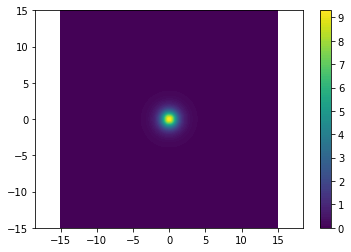

In [6]:
plt.contourf(ym, zm, getU(x0, ym, zm, nu, Re), levels=101, )
plt.axis('equal')
plt.colorbar()

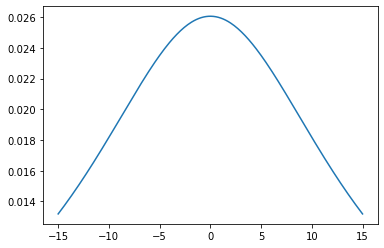

In [7]:
#plt.plot(yvec, Ux[:,Nz//2])
#plt.plot(yvec, V[:,Nz//2])
plt.plot(zvec, V[0,:])

## Set up RANS

In [8]:
# Set boundary conditions
ubc = {}
ubc['ylo'] = {'type':'dirichlet', 'value':0.0}
ubc['yhi'] = {'type':'dirichlet', 'value':0.0}
ubc['zlo'] = {'type':'dirichlet', 'value':0.0}
ubc['zhi'] = {'type':'dirichlet', 'value':0.0}

vbc = {}
vbc['ylo'] = {'type':'dirichlet', 'value':0.07}
vbc['yhi'] = {'type':'dirichlet', 'value':0.0}
vbc['zlo'] = {'type':'dirichlet', 'value':0.0}
vbc['zhi'] = {'type':'dirichlet', 'value':0.0}

wbc = {}
wbc['ylo'] = {'type':'dirichlet', 'value':0.0}
wbc['yhi'] = {'type':'dirichlet', 'value':0.0}
wbc['zlo'] = {'type':'dirichlet', 'value':0.0}
wbc['zhi'] = {'type':'dirichlet', 'value':0.0}

allbc = {'u':ubc, 'v':vbc, 'w':wbc}

In [9]:
dy   = np.mean(np.diff(yvec))
dz   = np.mean(np.diff(zvec))
print(dy)
print(dz)

0.12048192771084337
0.12048192771084337


In [10]:
# Set parameters
params = {}
params['nu']=nu

In [11]:
phiinit = {}
phiinit['u'] = Ux
phiinit['v'] = V
phiinit['w'] = W

In [12]:
dx  = 1
#xvec = np.arange(xvecplot[0], xvecplot[-1]+1.0E-6, dx)
#xvec = [x0, x0+dx, x0+2*dx, x0+3*dx]
xvec = np.arange(xvecplot[0], xvecplot[-1]+1.0E-6, dx)
phi = SANDwake3D.marchSystem(phiinit, xvec, dy, dz, params, allbc, SANDwake3D.laminar_eqns, 
                             verbose=True, maxiter=200, tol=1.0E-4)

x = 21.0 dx = 1.0
0 {'u': 3.815260526069009, 'w': 4.992944998892041, 'v': 33.82208516522458}
1 {'u': 9.99614422269001, 'w': 1.6262023064955309, 'v': 34.63929475197673}
2 {'u': 10.185896427896232, 'w': 0.7195307210952471, 'v': 57.04556583690708}
3 {'u': 4.228636929228216, 'w': 2.003717539365801, 'v': 60.50442407120332}
4 {'u': 4.473430994173047, 'w': 0.7519598035499977, 'v': 17.869704887901495}
5 {'u': 3.620940358740227, 'w': 1.283781359562686, 'v': 24.04632857828612}
6 {'u': 3.8206562775213353, 'w': 0.7910649644142078, 'v': 12.509408323259775}
7 {'u': 2.7582856189425167, 'w': 0.8614176176836887, 'v': 19.97473796259811}
8 {'u': 2.3196218269353968, 'w': 0.608380050100547, 'v': 6.573041377368902}
9 {'u': 1.8465868526325153, 'w': 0.32458532061834755, 'v': 7.829380848365344}
10 {'u': 1.3635930225392812, 'w': 0.5159193538033447, 'v': 5.5611026292954495}
11 {'u': 1.2799224966930454, 'w': 0.10538047406734458, 'v': 3.714056949178448}
12 {'u': 0.8629548342216471, 'w': 0.2811069563194457, 'v': 4.

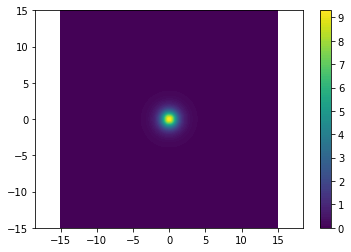

In [13]:
plt.contourf(ym, zm, phi['u'][0,:,:], levels=101, )
plt.axis('equal')
plt.colorbar()

20
22
26


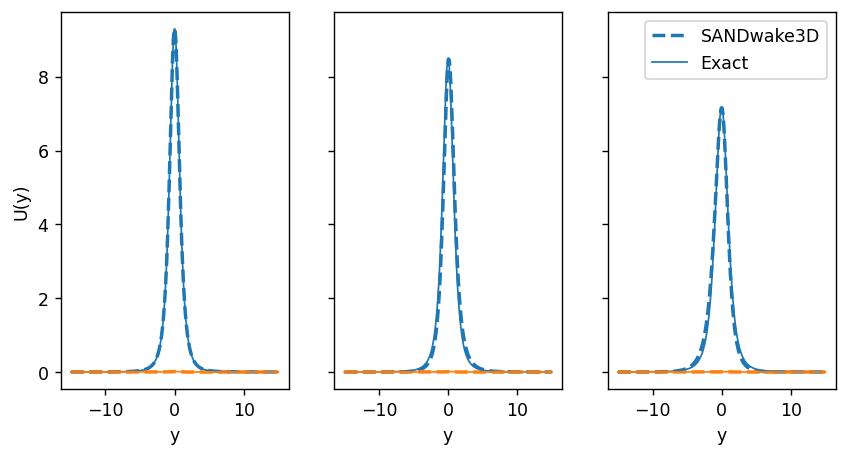

In [14]:
fig, axs = plt.subplots(1, len(xvecplot), figsize=(8,4), dpi=125, sharey=True)
for ix, x in enumerate(xvecplot):
    ixRANS = find_nearest(xvec, x) 
    iz = Nz//2
    lu = axs[ix].plot(yvec, phi['u'][ixRANS,:,iz], '--', lw=2, label='SANDwake3D')
    #lv = axs[ix].plot(yvec, phi['v'][ixRANS,:,iz], '--', lw=2, )
    lw = axs[ix].plot(yvec, phi['w'][ixRANS,:,iz], '--', lw=2, )
    
    print(x)
    # Exact solution
    Uexact = getU(x, ym, zm, nu, Re)
    Urexact = getV(x, ym, zm, nu, Re)
    # Map to (y,z) coordinates
    Vexact  = Urexact*ny
    Wexact  = Urexact*nz
    
    axs[ix].plot(yvec, Uexact[:,iz], '-', color=lu[0].get_color(), lw=1, label='Exact')
    #axs[ix].plot(yvec, Vexact[:,iz], '-', color=lv[0].get_color(), lw=1, )
    axs[ix].plot(yvec, Wexact[:,iz], '-', color=lw[0].get_color(), lw=1, )
    
axs[-1].legend()
axs[0].set_ylabel('U(y)')
for ax in axs:
    ax.set_xlabel('y')